In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print(f"Libraries imported")
print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")

Libraries imported
Pandas version: 2.3.3
Numpy version: 1.26.4


In [3]:
print(f"Loading data...")

counts = pd.read_csv('../data/GSE138852_counts.csv', index_col=0)
metadata = pd.read_csv('../data/GSE138852_covariates.csv', index_col=0)

print(f"Genes (rows): {counts.shape[0]:,}")
print(f"Cells (colums) : {counts.shape[1]:,}")
print(f"Metadata samples : {metadata.shape[0]:,}")
print(f"Metadata variable : {metadata.shape[1]:,}")

Loading data...
Genes (rows): 10,850
Cells (colums) : 13,214
Metadata samples : 13,214
Metadata variable : 5


In [4]:
counts[metadata.index]


,AAACCTGGTAGAAAGG_AD5_AD6,AAACCTGGTAGCGATG_AD5_AD6,AAACCTGTCAGTCAGT_AD5_AD6,AAACCTGTCCAAACAC_AD5_AD6,AAACCTGTCCAGTATG_AD5_AD6,AAAGCAACATGGGAAC_AD5_AD6,AAAGCAAGTCGAATCT_AD5_AD6,AAAGCAAGTTTGTTGG_AD5_AD6,AAAGTAGGTAATCACC_AD5_AD6,AAAGTAGGTTCCACGG_AD5_AD6,...,TTTGGTTAGCCACGCT_AD1_AD2,TTTGGTTCAACTTGAC_AD1_AD2,TTTGGTTCAGCCTTTC_AD1_AD2,TTTGGTTCATCGGACC_AD1_AD2,TTTGGTTTCCCAGGTG_AD1_AD2,TTTGGTTTCCGTACAA_AD1_AD2,TTTGTCACAAGCCATT_AD1_AD2,TTTGTCAGTATAGGTA_AD1_AD2,TTTGTCATCCACTGGG_AD1_AD2,TTTGTCATCCGGGTGT_AD1_AD2
FO538757.2,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
AP006222.2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
RP5-857K21.4,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
RP11-206L10.9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
NOC2L,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MT-ND5,0,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
MT-CYB,0,0,1,0,0,3,0,1,2,0,...,0,0,1,0,0,0,0,1,1,2
AL592183.1,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AC007325.4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
print(metadata.columns.tolist())
print(f"\nCelltypes:")
print(metadata['oupSample.cellType'].value_counts())
print(f"\nConditions:")
print(metadata['oupSample.batchCond'].value_counts())
print("\n")
print(metadata['oupSample.cellType_batchCond'].value_counts())
print("\n")
print(metadata['oupSample.subclustID'].value_counts())
print("\n")
print(metadata['oupSample.subclustCond'].value_counts())

['oupSample.batchCond', 'oupSample.cellType', 'oupSample.cellType_batchCond', 'oupSample.subclustID', 'oupSample.subclustCond']

Celltypes:
oupSample.cellType
oligo      7432
astro      2171
OPC        1078
unID        925
neuron      656
mg          449
doublet     405
endo         98
Name: count, dtype: int64

Conditions:
oupSample.batchCond
AD    6673
ct    6541
Name: count, dtype: int64


oupSample.cellType_batchCond
oligo_AD      4655
oligo_ct      2777
astro_ct      1699
OPC_ct         899
unID_AD        614
astro_AD       472
neuron_ct      407
unID_ct        311
doublet_AD     295
mg_ct          277
neuron_AD      249
OPC_AD         179
mg_AD          172
doublet_ct     110
endo_ct         61
endo_AD         37
Name: count, dtype: int64


oupSample.subclustID
o2    2025
o6    1902
o1    1881
o5     827
o3     638
a5     600
a7     447
O4     415
a3     262
u7     256
O2     254
O3     238
a1     222
a2     219
a8     207
n5     192
u4     187
O1     171
m3     163
o4     159
u3

In [8]:
#calculate QC metrics

total_counts_per_cell = counts.sum(axis=0)
n_genes_per_cell = (counts > 0).sum(axis =0 )

# Print summary statistics
print("Total counts per cell:")
print(total_counts_per_cell.describe())

print("\nNumber of genes per cell:")
print(n_genes_per_cell.describe())

#Median cell: Has 917 total RNA molecules (across all genes combined) || Expressed 646 different genes (out of 10,850 possible genes)

Total counts per cell:
count    13214.000000
mean      1026.540412
std        504.702999
min        328.000000
25%        669.000000
50%        917.000000
75%       1264.000000
max       2808.000000
dtype: float64

Number of genes per cell:
count    13214.000000
mean       701.952323
std        282.977507
min        274.000000
25%        498.000000
50%        646.000000
75%        852.000000
max       1632.000000
dtype: float64


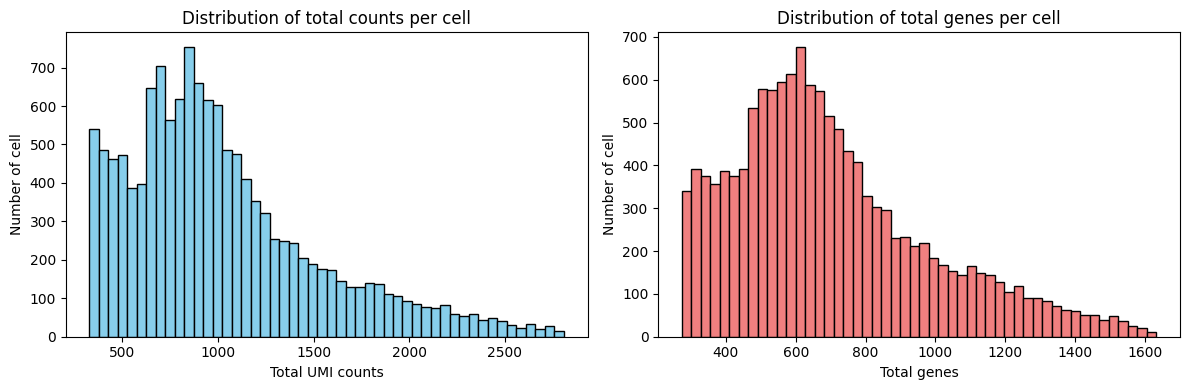

In [9]:
#visualize the data

fig, axes = plt.subplots(1,2,figsize = (12,4))

#Total counts distribution
axes[0].hist(total_counts_per_cell, bins=50, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Total UMI counts')
axes[0].set_ylabel('Number of cell')
axes[0].set_title('Distribution of total counts per cell')

axes[1].hist(n_genes_per_cell, bins=50, color='lightcoral', edgecolor='black')
axes[1].set_xlabel('Total genes')
axes[1].set_ylabel('Number of cell')
axes[1].set_title('Distribution of total genes per cell')

plt.tight_layout()
plt.show()

In [10]:
#which celltype has the highest rna count
qc_data = pd.DataFrame({
    'total_counts': total_counts_per_cell,
    'n_genes': n_genes_per_cell
})

# Add cell type info
qc_data['cell_type'] = metadata['oupSample.cellType']

# Calculate mean QC by cell type
qc_by_celltype = qc_data.groupby('cell_type')[['total_counts', 'n_genes']].mean()

print(qc_by_celltype.sort_values('total_counts', ascending=False))

           total_counts     n_genes
cell_type                          
astro       1527.320129  970.188853
neuron      1392.629573  930.833841
OPC         1298.648423  884.528757
endo         978.693878  640.642857
doublet      960.180247  701.555556
oligo        879.608315  614.795344
mg           845.472160  593.026726
unID         577.009730  457.111351


In [12]:
#filter the doublets and unID cell types

#before filtering
print(metadata['oupSample.cellType'].value_counts())

#keep only 6 cell types
clean_Cell_types = ['astro', 'neuron','OPC','endo','oligo','mg']
keep_cells = metadata['oupSample.cellType'].isin(clean_Cell_types)

metadata_clean = metadata[keep_cells]
counts_clean = counts[metadata_clean.index]

#after filtering
print(metadata_clean['oupSample.cellType'].value_counts())
print(f"\nTotal cells kept :{len(metadata_clean)} out of {len(metadata)}")


oupSample.cellType
oligo      7432
astro      2171
OPC        1078
unID        925
neuron      656
mg          449
doublet     405
endo         98
Name: count, dtype: int64
oupSample.cellType
oligo     7432
astro     2171
OPC       1078
neuron     656
mg         449
endo        98
Name: count, dtype: int64

Total cells kept :11884 out of 13214


In [13]:
# Check AD vs Control in clean data
print("AD vs Control distribution (after filtering):")
print(metadata_clean['oupSample.batchCond'].value_counts())

# Check by cell type
print("\nCell types by condition:")
ct_by_cond = pd.crosstab(metadata_clean['oupSample.cellType'], 
                          metadata_clean['oupSample.batchCond'])
print(ct_by_cond)

AD vs Control distribution (after filtering):
oupSample.batchCond
ct    6120
AD    5764
Name: count, dtype: int64

Cell types by condition:
oupSample.batchCond    AD    ct
oupSample.cellType             
OPC                   179   899
astro                 472  1699
endo                   37    61
mg                    172   277
neuron                249   407
oligo                4655  2777


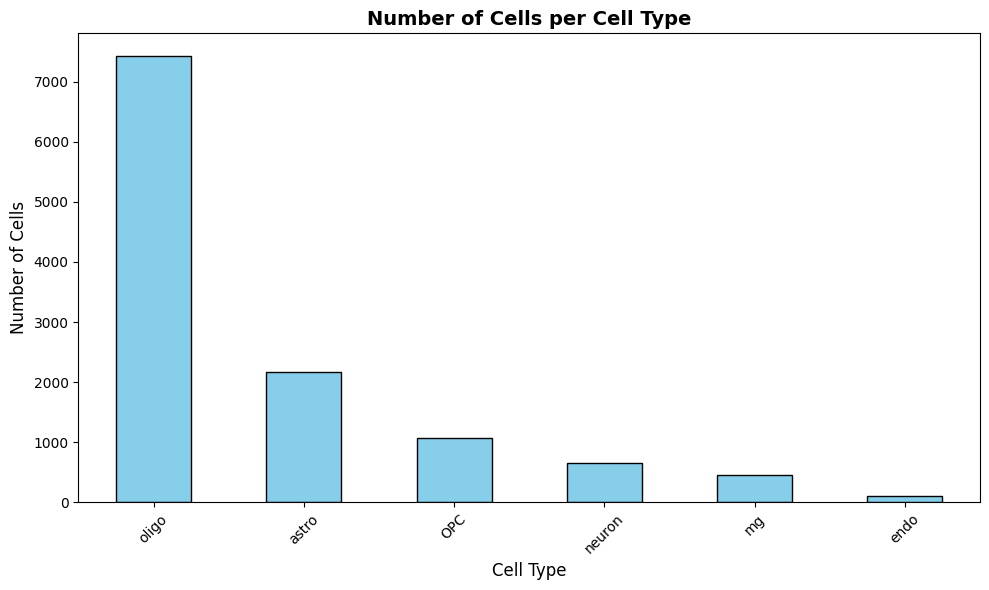

oupSample.cellType
oligo     7432
astro     2171
OPC       1078
neuron     656
mg         449
endo        98
Name: count, dtype: int64


In [14]:
# Count cells per type
cell_counts = metadata_clean['oupSample.cellType'].value_counts()

# Create bar plot
plt.figure(figsize=(10, 6))
cell_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Number of Cells per Cell Type', fontsize=14, fontweight='bold')
plt.xlabel('Cell Type', fontsize=12)
plt.ylabel('Number of Cells', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(cell_counts)

In [ ]:
# Create grouped counts
grouped = metadata_clean.groupby(['oupSample.cellType', 'oupSample.batchCond']).size().unstack(fill_value=0)

# Create grouped bar plot
grouped.plot(kind='bar', figsize=(10, 6), color=['salmon', 'lightgreen'], edgecolor='black')
plt.title('Cell Types: AD vs Control', fontsize=14, fontweight='bold')
plt.xlabel('Cell Type', fontsize=12)
plt.ylabel('Number of Cells', fontsize=12)
plt.legend(['AD', 'Control'], title='Condition')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nCounts:")
print(grouped)

In [19]:
#normalize the counts: counts per 10,000 (CP10K)

#calculate total counts per cell 
total_counts_clean = counts_clean.sum(axis=0)
#normalize
counts_normalized = (counts_clean / total_counts_clean) * 10000

# Log transform: log(x + 1) to reduce skewness
counts_log = np.log1p(counts_normalized)

print("Original counts shape:", counts_clean.shape)
print("Normalized counts shape:", counts_normalized.shape)
print("Log-transformed counts shape:", counts_log.shape)

# Check a few values
print("\nExample - first gene, first 5 cells:")
print("Original:", counts_clean.iloc[0, :50].values)
print("Normalized:", counts_normalized.iloc[0, :50].values)
print("Log-transformed:", counts_log.iloc[0, :50].values)

Original counts shape: (10850, 11884)
Normalized counts shape: (10850, 11884)
Log-transformed counts shape: (10850, 11884)

Example - first gene, first 5 cells:
Original: [0 0 0 0 0 0 0 0 0 0 0 2 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1
 2 0 0 0 0 0 0 0 0 0 0 0 1]
Normalized: [ 0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.         18.36547291
  0.         12.91989664  0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.         10.82251082  0.          0.          0.          0.
 11.01321586 38.38771593  0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          6.58327847]
Log-transformed: [0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         2.96349173
 0.         2.633

In [22]:
counts_log.head()

,AAACCTGGTAGAAAGG_AD5_AD6,AAACCTGGTAGCGATG_AD5_AD6,AAACCTGTCAGTCAGT_AD5_AD6,AAACCTGTCCAAACAC_AD5_AD6,AAACCTGTCCAGTATG_AD5_AD6,AAAGCAAGTCGAATCT_AD5_AD6,AAAGCAAGTTTGTTGG_AD5_AD6,AAAGTAGGTAATCACC_AD5_AD6,AAAGTAGGTTCCACGG_AD5_AD6,AAATGCCCAAGACACG_AD5_AD6,...,TTTGCGCAGACCTAGG_AD1_AD2,TTTGCGCAGGAGTTTA_AD1_AD2,TTTGCGCGTCACACGC_AD1_AD2,TTTGCGCGTTACTGAC_AD1_AD2,TTTGCGCTCAATAAGG_AD1_AD2,TTTGCGCTCATATCGG_AD1_AD2,TTTGGTTCAACTTGAC_AD1_AD2,TTTGGTTTCCCAGGTG_AD1_AD2,TTTGGTTTCCGTACAA_AD1_AD2,TTTGTCATCCACTGGG_AD1_AD2
FO538757.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.000000,2.33658,0.0,3.19537,0.0,0.0,0.0,3.162282,0.000000
AP006222.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.000000,0.00000,0.0,0.00000,0.0,0.0,0.0,0.000000,0.000000
RP5-857K21.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.181991,0.0,...,0.0,2.513716,0.00000,0.0,0.00000,0.0,0.0,0.0,0.000000,2.527386
RP11-206L10.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.000000,0.00000,0.0,0.00000,0.0,0.0,0.0,0.000000,0.000000
NOC2L,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.000000,0.00000,0.0,0.00000,0.0,0.0,0.0,0.000000,0.000000


In [23]:
#selecting highly variable genes

gene_stats = pd.DataFrame({
    'mean':counts_log.mean(axis=1),  # Calculate mean ACROSS cells (for each gene)
    'variance': counts_log.var(axis=1),  # Calculate variance for each gene
    'n_cells': (counts_clean>0).sum(axis=1)  # Count non-zero cells per gene
})

min_cells = 50  # Gene must be expressed in at least 50 cells
min_var =0.5    # Gene must have variance > 0.5

#Apply filters
highly_variable_genes = gene_stats[
    (gene_stats['n_cells']>=min_cells) &
    (gene_stats['variance']>=min_var)
    ].index

print(f"Original genes: {counts_log.shape[0]}")
print(f"Highly variable genes: {len(highly_variable_genes)}")
print(f"Reduction: {len(highly_variable_genes) / counts_log.shape[0] * 100:.1f}%")

# Filter the data
counts_filtered = counts_log.loc[highly_variable_genes]
print(f"\nFiltered data shape: {counts_filtered.shape}")

Original genes: 10850
Highly variable genes: 2043
Reduction: 18.8%

Filtered data shape: (2043, 11884)


In [25]:
#prepare data for Ml
#transpose : make cells =rows, genes =columns

X= counts_filtered.T

y=metadata_clean['oupSample.cellType'] # Get labels (cell types)

print("Feature matrix (X) shape:", X.shape)
print("Labels (y) shape:", y.shape)

# Check they match
print(f"\nNumber of samples in X: {X.shape[0]}")
print(f"Number of samples in y: {len(y)}")
print(f"Number of features (genes): {X.shape[1]}")

# Show label distribution
print("\nLabel distribution:")
print(y.value_counts())

Feature matrix (X) shape: (11884, 2043)
Labels (y) shape: (11884,)

Number of samples in X: 11884
Number of samples in y: 11884
Number of features (genes): 2043

Label distribution:
oupSample.cellType
oligo     7432
astro     2171
OPC       1078
neuron     656
mg         449
endo        98
Name: count, dtype: int64


In [29]:
#train/test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,         # 20% for testing
    random_state =42,      # For reproducibility
    stratify =y           # Keep same cell type proportions in both sets
)

print("Training set:")
print(f"  X_train shape: {X_train.shape}")
print(f"  y_train shape: {y_train.shape}")

print("\nTest set:")
print(f"  X_test shape: {X_test.shape}")
print(f"  y_test shape: {y_test.shape}")


print("\nTrain set cell types:")
print(y_train.value_counts())

print("\nTest set cell types:")
print(y_test.value_counts())

Training set:
  X_train shape: (9507, 2043)
  y_train shape: (9507,)

Test set:
  X_test shape: (2377, 2043)
  y_test shape: (2377,)

Train set cell types:
oupSample.cellType
oligo     5946
astro     1737
OPC        862
neuron     525
mg         359
endo        78
Name: count, dtype: int64

Test set cell types:
oupSample.cellType
oligo     1486
astro      434
OPC        216
neuron     131
mg          90
endo        20
Name: count, dtype: int64


In [30]:
# Save the cleaned and preprocessed data
import pickle

# Save as pickle files (preserves pandas format)
X_train.to_pickle('../data/X_train.pkl')
X_test.to_pickle('../data/X_test.pkl')
y_train.to_pickle('../data/y_train.pkl')
y_test.to_pickle('../data/y_test.pkl')

#save the filtered counts for later use
counts_filtered.to_pickle('../data/counts_filtered.pkl')
metadata_clean.to_pickle('../data/metadata_clean.pkl')

print("✅ Data saved successfully!")
print("\nSaved files:")
print("  - X_train.pkl (training features)")
print("  - X_test.pkl (test features)")
print("  - y_train.pkl (training labels)")
print("  - y_test.pkl (test labels)")
print("  - counts_filtered.pkl (preprocessed counts)")
print("  - metadata_clean.pkl (clean metadata)")

✅ Data saved successfully!

Saved files:
  - X_train.pkl (training features)
  - X_test.pkl (test features)
  - y_train.pkl (training labels)
  - y_test.pkl (test labels)
  - counts_filtered.pkl (preprocessed counts)
  - metadata_clean.pkl (clean metadata)


In [31]:
#train a random forest classifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import time

#create the model
rf_model = RandomForestClassifier(
    n_estimators =100,
    max_depth = 20,
    random_state = 42,
        n_jobs=-1
)

print("training")
start_time=time.time()

rf_model.fit(X_train, y_train)

train_time=time.time() - start_time

print(f"✅ Training completed in {train_time:.2f} seconds")


training
✅ Training completed in 1.00 seconds


In [32]:
# Make predictions on test set
y_pred = rf_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\n🎯 Test Accuracy: {accuracy * 100:.2f}%")

# Detailed report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


🎯 Test Accuracy: 98.57%

Classification Report:
              precision    recall  f1-score   support

         OPC       0.98      0.99      0.99       216
       astro       0.99      0.99      0.99       434
        endo       1.00      0.65      0.79        20
          mg       1.00      0.89      0.94        90
      neuron       0.99      0.95      0.97       131
       oligo       0.98      1.00      0.99      1486

    accuracy                           0.99      2377
   macro avg       0.99      0.91      0.94      2377
weighted avg       0.99      0.99      0.99      2377



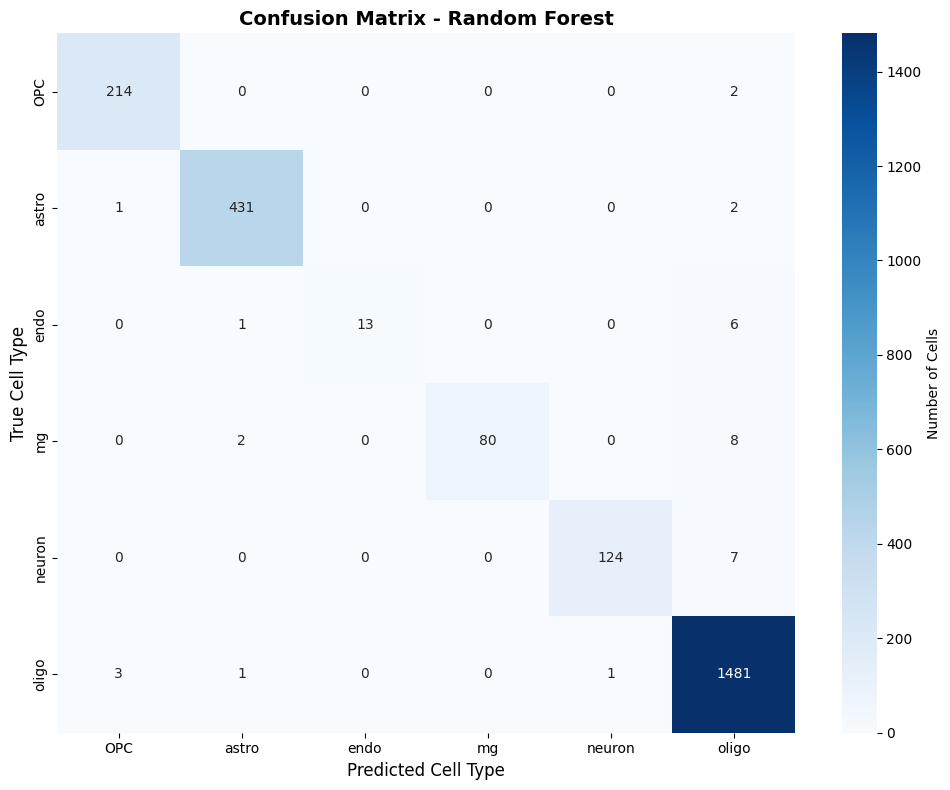

✅ Confusion matrix saved!


In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot it
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=rf_model.classes_, 
            yticklabels=rf_model.classes_,
            cbar_kws={'label': 'Number of Cells'})
plt.xlabel('Predicted Cell Type', fontsize=12)
plt.ylabel('True Cell Type', fontsize=12)
plt.title('Confusion Matrix - Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/confusion_matrix_rf.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Confusion matrix saved!")

In [34]:
import pickle

# Save the trained Random Forest model
with open('../results/models/random_forest_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

print("✅ Model saved successfully!")
print("\nSaved to: results/models/random_forest_model.pkl")
print(f"\nModel performance: {accuracy * 100:.2f}% accuracy")
print(f"Trained on: {len(X_train)} cells")
print(f"Tested on: {len(X_test)} cells")

✅ Model saved successfully!

Saved to: results/models/random_forest_model.pkl

Model performance: 98.57% accuracy
Trained on: 9507 cells
Tested on: 2377 cells
